In [93]:
import pandas as pd
import matplotlib.pyplot as plt


tourney_df = pd.read_pickle('pickle/tourney_w_brackets_df.p')

In [94]:
tourney_df = tourney_df[
    (tourney_df['Iowa'] > 2) 
    & (tourney_df['Purdue'] > 2)
    & (tourney_df['Arizona'] > 3)
    & (tourney_df['Illinois'] > 3)
    & (tourney_df['Duke'] > 2)
    & (tourney_df['Michigan'] > 3)
    & (tourney_df['Connecticut'] > 3)
    & (tourney_df['Tennessee'] > 2)
    ]
tourney_df.Probability = tourney_df.Probability / tourney_df.Probability.sum()

In [95]:
win_df = tourney_df[['Winner', 'Probability']].groupby(['Winner']).sum()
win_df.sort_values(by='Probability', ascending=False, inplace=True)

win_df_nice = win_df.copy()
win_df_nice = win_df_nice.loc[win_df_nice['Probability'] > 0.00000005]
other = 1.0 - win_df_nice['Probability'].sum()
if other > 0.0001:
    win_df_nice.loc['Other'] = [other]

second_df = tourney_df[['Second', 'Probability']].groupby(['Second']).sum()
second_df.sort_values(by='Probability', ascending=False, inplace=True)

second_df_nice = second_df.copy()
second_df_nice = second_df_nice.loc[second_df_nice['Probability'] > 0.03]
other = 1.0 - second_df_nice['Probability'].sum()
if other > 0.0001:
    second_df_nice.loc['Other'] = [other]

third_df = tourney_df[['Third', 'Probability']].groupby(['Third']).sum()
third_df.sort_values(by='Probability', ascending=False, inplace=True)

third_df_nice = third_df.copy()
third_df_nice = third_df_nice.loc[third_df_nice['Probability'] > 0.00000005]
other = 1.0 - third_df_nice['Probability'].sum()
if other > 0.0001:
    third_df_nice.loc['Other'] = [other]


In [96]:
all_labels = set(win_df_nice.index) | set(second_df_nice.index) | set(third_df_nice.index)

In [97]:
def get_color_list(n, step, floor, start=0):
    ang = 2 * pi * step/n
    R = sqrt(1/3)
    k = 1 - floor
    coords = [[sqrt(6) / 3, R * cos(i * ang), R * sin(i * ang)] for i in range(n)]
    M = [[sqrt(3)/3, -sqrt(3)/3, -sqrt(3)/3],
         [sqrt(3)/3, (3+sqrt(3))/6, -(3-sqrt(3))/6],
         [sqrt(3)/3,  -(3-sqrt(3))/6, (3+sqrt(3))/6]]
    colors = []
    for xyz in coords:
        new = [floor + k * sum(a*b for a, b in zip(xyz, row)) for row in M]
        colors.append(new)
        # floor += (1 - floor) / n
        # k = 1 - floor
        x, y, z = xyz        
    return colors

In [98]:
from math import sin, cos, sqrt, gcd, pi

seen = set()
final_labels = []
for label in all_labels:
    if label not in seen:
        final_labels.append(label)
        seen.add(label)
        
for label in sorted(seen):
    print(label)
        
n = len(final_labels)
step = 1
while gcd(step, n) > 1:
    step += 1
floor = 0.5
colors = get_color_list(n, step, floor, start=0)
color_dict = {label: color for label, color in zip(final_labels, colors)}

color_dict

Danny Ryan
George Wright
Justin Calvillo
Keith Schneider
Koy Kubasta
Mark Hurst
Nathan Sanches
Patrick Commers
Serigne Diaw


{'Patrick Commers': [0.5690355937288492,
  0.9633731610262555,
  0.6746980264314426],
 'Serigne Diaw': [0.5008969182612629, 0.870895522953062, 0.8353143399722224],
 'George Wright': [0.5426262719489927, 0.7151594548234427, 0.949321054414112],
 'Mark Hurst': [0.6746980264314426, 0.5690355937288492, 0.9633731610262555],
 'Keith Schneider': [0.8353143399722224,
  0.5008969182612629,
  0.8708955229530622],
 'Danny Ryan': [0.949321054414112, 0.5426262719489927, 0.7151594548234427],
 'Justin Calvillo': [0.9633731610262556,
  0.6746980264314426,
  0.5690355937288493],
 'Nathan Sanches': [0.8708955229530622,
  0.8353143399722223,
  0.5008969182612629],
 'Koy Kubasta': [0.7151594548234428, 0.949321054414112, 0.5426262719489927]}

In [99]:
dfs = [win_df_nice, second_df_nice, third_df_nice]
disp_titles = ['1st Place', '2nd Place', '3rd Place']

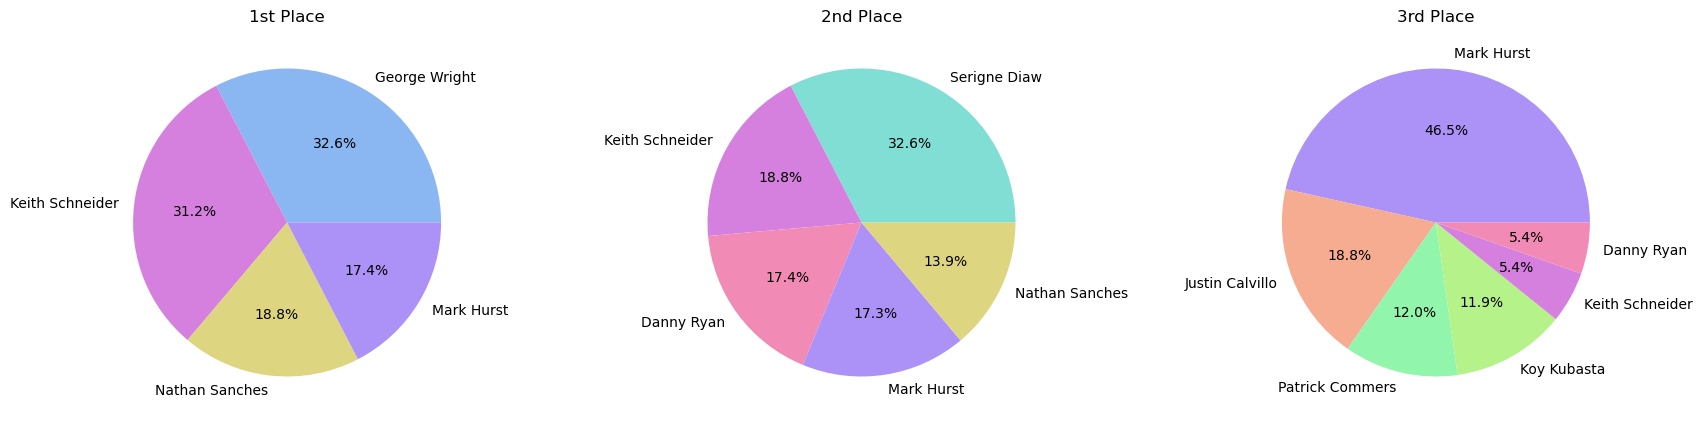

In [100]:
fig, axs = plt.subplots(1, 3, figsize = [21, 5])

for ax, title, df in zip(axs.flatten(), disp_titles, dfs):
    labels=df.index
    colors = [color_dict[label] for label in labels]
    labels = [_.replace(', ', ',\n') for _ in labels]
    ax.pie(df['Probability'], 
           labels=labels,
           autopct='%1.1f%%',
           normalize=True,
           colors=colors)
    ax.set(ylabel='', title=title, aspect='equal')

plt.savefig('plots/win_place_show_final_four.png', dpi=300, bbox_inches='tight')

In [101]:
pot = 425.0
prizes = {
    1: 0.6 * pot,
    2: 0.3 * pot,
    3: .01 * pot
}

ev_dict = {}

for winner in win_df.index:
    winners = winner.split(', ')
    prob = win_df.loc[winner, 'Probability']
    nwinners = len(winners)
    if nwinners == 1:
        total_prize = prizes[1]
    elif nwinners == 2:
        total_prize = prizes[1] + prizes[2]
    else:
        total_prize = prizes[1] + prizes[2] + prizes[3]
    share = prob * total_prize / nwinners
    for name in winners:
        if name not in ev_dict:
            ev_dict[name] = 0
        ev_dict[name] += share 

for winner in second_df.index:
    if winner == 'none':
        continue
    winners = winner.split(', ')
    prob = second_df.loc[winner, 'Probability']
    nwinners = len(winners)
    if nwinners == 1:
        total_prize = prizes[2]
    else:
        total_prize = prizes[2] + prizes[3]

    share = prob * total_prize / nwinners
    for name in winners:
        if name not in ev_dict:
            ev_dict[name] = 0
        ev_dict[name] += share 

for winner in third_df.index:
    if winner == 'none':
        continue
    winners = winner.split(', ')
    prob = third_df.loc[winner, 'Probability']
    nwinners = len(winners)
    total_prize = prizes[3]

    share = prob * total_prize / nwinners
    for name in winners:
        if name not in ev_dict:
            ev_dict[name] = 0
        ev_dict[name] += share 
# ev_dict

ev_df = pd.DataFrame.from_dict(data=ev_dict, orient='index', columns=['EV (USD)'])
ev_df.sort_values(by='EV (USD)', ascending=False, inplace=True)
ev_df['EV (GBP)'] = ev_df['EV (USD)']  * 0.75
ev_df
    

,EV (USD),EV (GBP)
Keith Schneider,103.774809,77.831107
George Wright,83.152302,62.364226
Mark Hurst,68.418532,51.313899
Nathan Sanches,65.611819,49.208864
Serigne Diaw,41.576151,31.182113
Danny Ryan,22.402741,16.802056
Justin Calvillo,0.797271,0.597954
Patrick Commers,0.508810,0.381608
Koy Kubasta,0.507565,0.380673


In [102]:
from IPython.display import display

display(ev_df.style.format({
    'EV (USD)': '${:,.2f}',
    'EV (GBP)': '£{:,.2f}' # Example for a different currency without decimals
}))



,EV (USD),EV (GBP)
Keith Schneider,$103.77,£77.83
George Wright,$83.15,£62.36
Mark Hurst,$68.42,£51.31
Nathan Sanches,$65.61,£49.21
Serigne Diaw,$41.58,£31.18
Danny Ryan,$22.40,£16.80
Justin Calvillo,$0.80,£0.60
Patrick Commers,$0.51,£0.38
Koy Kubasta,$0.51,£0.38


In [103]:
print(ev_df)

                   EV (USD)   EV (GBP)
Keith Schneider  103.774809  77.831107
George Wright     83.152302  62.364226
Mark Hurst        68.418532  51.313899
Nathan Sanches    65.611819  49.208864
Serigne Diaw      41.576151  31.182113
Danny Ryan        22.402741  16.802056
Justin Calvillo    0.797271   0.597954
Patrick Commers    0.508810   0.381608
Koy Kubasta        0.507565   0.380673


In [104]:
pd.set_option('display.max_colwidth', 70)
print(win_df)

                 Probability
Winner                      
George Wright       0.326087
Keith Schneider     0.312114
Nathan Sanches      0.187886
Mark Hurst          0.173913


In [105]:
pd.set_option('display.max_colwidth', 70)
print(second_df)

                 Probability
Second                      
Serigne Diaw        0.326087
Keith Schneider     0.187886
Danny Ryan          0.173913
Mark Hurst          0.173284
Nathan Sanches      0.138830


In [106]:
pd.set_option('display.max_colwidth', 70)
print(third_df)

                 Probability
Third                       
Mark Hurst          0.465210
Justin Calvillo     0.187593
Patrick Commers     0.119720
Koy Kubasta         0.119427
Keith Schneider     0.054193
Danny Ryan          0.053857
